In [6]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import pandas as pd

In [8]:
file_path = "/content/drive/MyDrive/colab/traffic_flow_clustering_dataset_clean (1).csv"

In [9]:
df = pd.read_csv(file_path)
# Display the first 5 rows

df.head()

,Record_ID,Hour,Day_of_Week,Vehicle_Count,Average_Speed_kmph,Traffic_Density_veh_per_km,Road_Occupancy_percent,Traffic_Condition
0,1,5,0,19.0,53.63,16.95,10.64,Low
1,2,13,1,282.0,21.52,58.25,64.57,High
2,3,21,6,114.0,36.43,27.77,39.43,Moderate
3,4,3,0,125.0,47.47,52.63,26.83,Moderate
4,5,23,5,22.0,63.71,13.69,14.19,Low


In [10]:
# Display number of rows and columns

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 588
Number of columns: 8


In [11]:
# Display all column names

print(df.columns.tolist())

['Record_ID', 'Hour', 'Day_of_Week', 'Vehicle_Count', 'Average_Speed_kmph', 'Traffic_Density_veh_per_km', 'Road_Occupancy_percent', 'Traffic_Condition']


In [12]:
# Display information about columns and their data types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588 entries, 0 to 587
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Record_ID                   588 non-null    int64  
 1   Hour                        588 non-null    int64  
 2   Day_of_Week                 588 non-null    int64  
 3   Vehicle_Count               588 non-null    float64
 4   Average_Speed_kmph          588 non-null    float64
 5   Traffic_Density_veh_per_km  588 non-null    float64
 6   Road_Occupancy_percent      588 non-null    float64
 7   Traffic_Condition           588 non-null    object 
dtypes: float64(4), int64(3), object(1)
memory usage: 36.9+ KB


In [13]:
# Generate statistical summary

df.describe()

,Record_ID,Hour,Day_of_Week,Vehicle_Count,Average_Speed_kmph,Traffic_Density_veh_per_km,Road_Occupancy_percent
count,588.000000,588.000000,588.000000,588.000000,588.000000,588.000000,588.000000
mean,300.714286,11.937075,3.010204,116.375850,42.860561,40.025476,39.859575
std,172.956662,6.993630,2.005078,77.265796,15.331316,21.721965,21.316337
min,1.000000,0.000000,0.000000,15.000000,10.030000,10.000000,10.120000
25%,151.750000,6.000000,1.000000,58.000000,31.007500,22.510000,22.692500
50%,299.500000,12.000000,3.000000,89.000000,44.730000,34.105000,32.690000
75%,451.250000,18.000000,5.000000,161.000000,54.347500,53.952500,54.097500
max,600.000000,23.000000,6.000000,300.000000,69.960000,89.820000,89.700000


In [14]:
# Check the number of missing values in each column

print(df.isnull().sum())

Record_ID                     0
Hour                          0
Day_of_Week                   0
Vehicle_Count                 0
Average_Speed_kmph            0
Traffic_Density_veh_per_km    0
Road_Occupancy_percent        0
Traffic_Condition             0
dtype: int64


In [15]:
# Count duplicate rows

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [16]:
# Display unique traffic conditions

print(df["Traffic_Condition"].unique())

['Low' 'High' 'Moderate']


In [17]:
# Count the number of records in each traffic condition

print(df["Traffic_Condition"].value_counts())

Traffic_Condition
Low         237
Moderate    194
High        157
Name: count, dtype: int64


In [18]:
# Import libraries for creating graphs

import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean plotting style

sns.set_style("whitegrid")

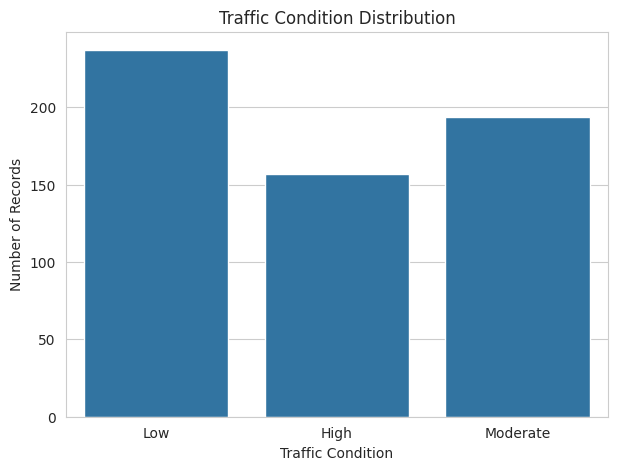

In [19]:
# Plot the number of observations in each traffic condition

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Traffic_Condition")

plt.title("Traffic Condition Distribution")
plt.xlabel("Traffic Condition")
plt.ylabel("Number of Records")

plt.show()

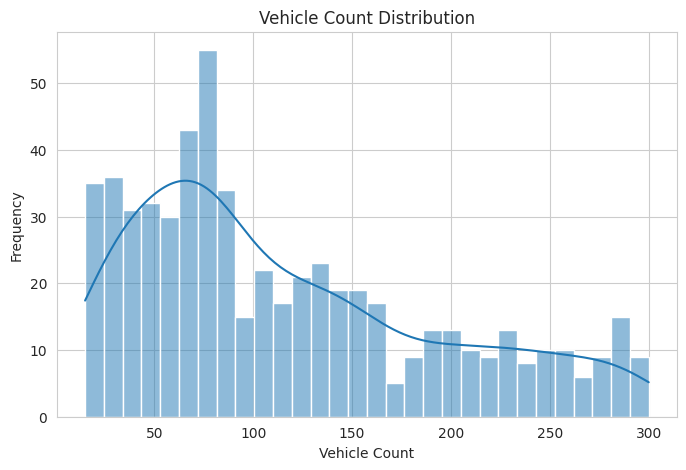

In [20]:
# Plot distribution of vehicle count

plt.figure(figsize=(8, 5))

sns.histplot(df["Vehicle_Count"].dropna(), bins=30, kde=True)

plt.title("Vehicle Count Distribution")
plt.xlabel("Vehicle Count")
plt.ylabel("Frequency")

plt.show()

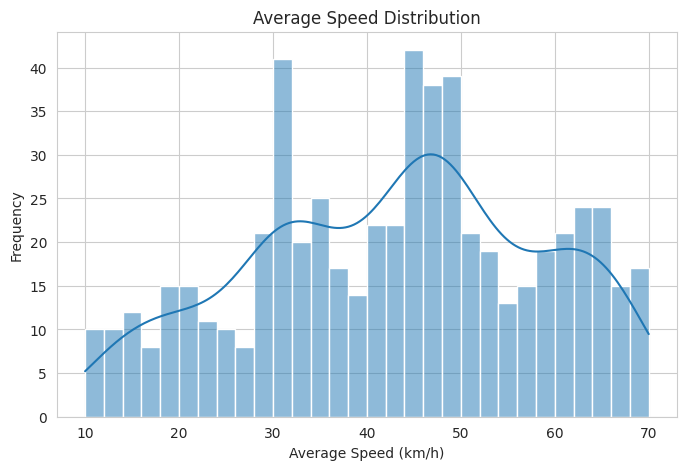

In [21]:
# Plot distribution of average speed

plt.figure(figsize=(8, 5))

sns.histplot(
    df["Average_Speed_kmph"].dropna(),
    bins=30,
    kde=True
)

plt.title("Average Speed Distribution")
plt.xlabel("Average Speed (km/h)")
plt.ylabel("Frequency")

plt.show()

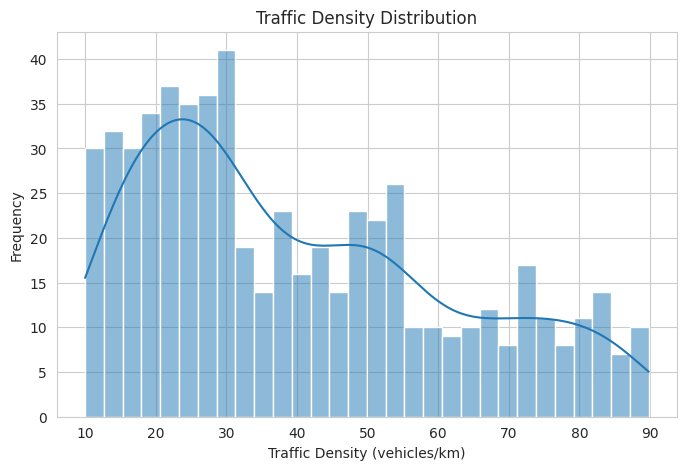

In [22]:
# Plot distribution of traffic density

plt.figure(figsize=(8, 5))

sns.histplot(
    df["Traffic_Density_veh_per_km"].dropna(),
    bins=30,
    kde=True
)

plt.title("Traffic Density Distribution")
plt.xlabel("Traffic Density (vehicles/km)")
plt.ylabel("Frequency")

plt.show()

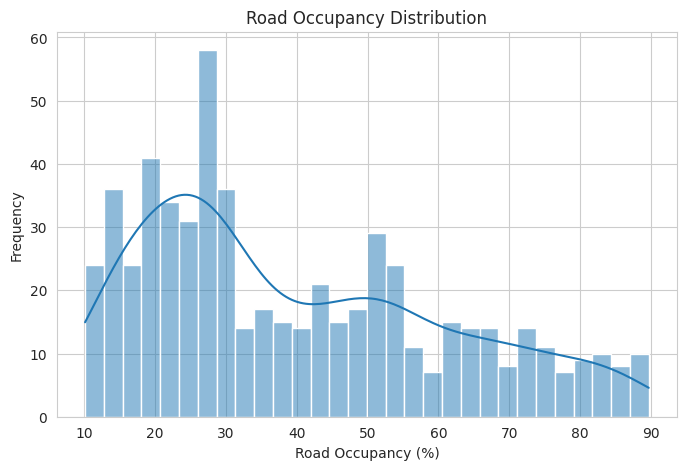

In [23]:
# Plot distribution of road occupancy

plt.figure(figsize=(8, 5))

sns.histplot(
    df["Road_Occupancy_percent"].dropna(),
    bins=30,
    kde=True
)

plt.title("Road Occupancy Distribution")
plt.xlabel("Road Occupancy (%)")
plt.ylabel("Frequency")

plt.show()

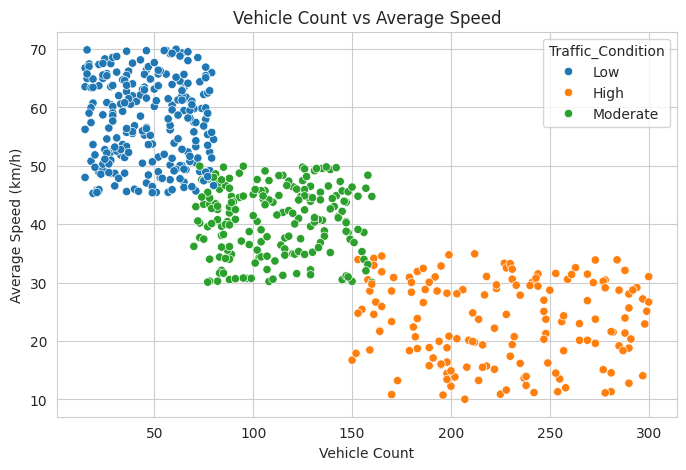

In [24]:
# Compare vehicle count and average speed

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Vehicle_Count",
    y="Average_Speed_kmph",
    hue="Traffic_Condition"
)

plt.title("Vehicle Count vs Average Speed")
plt.xlabel("Vehicle Count")
plt.ylabel("Average Speed (km/h)")

plt.show()

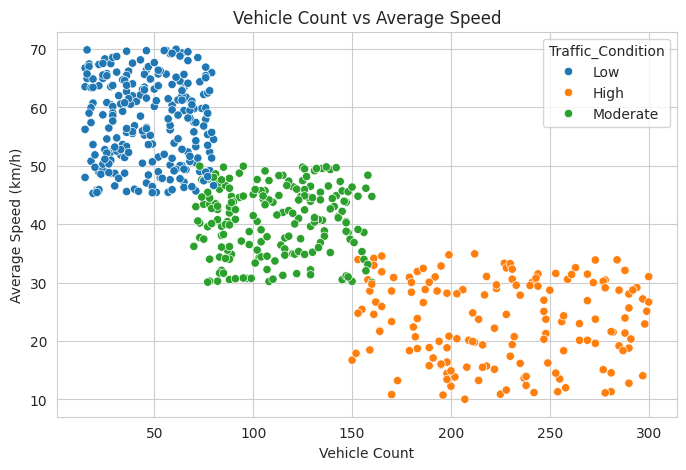

In [25]:
# Compare vehicle count and average speed

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Vehicle_Count",
    y="Average_Speed_kmph",
    hue="Traffic_Condition"
)

plt.title("Vehicle Count vs Average Speed")
plt.xlabel("Vehicle Count")
plt.ylabel("Average Speed (km/h)")

plt.show()

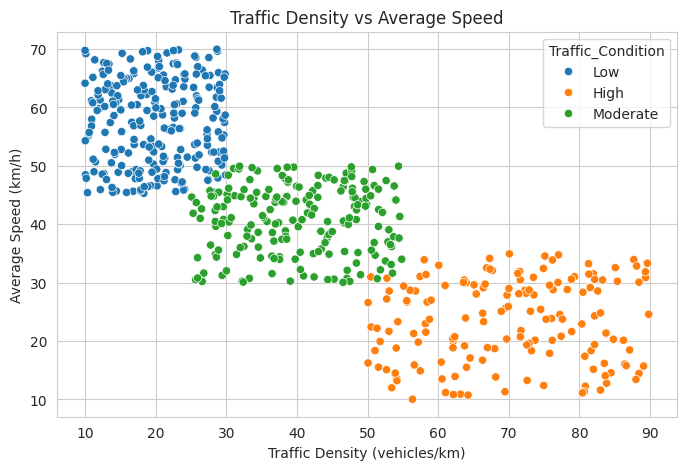

In [26]:
# Compare traffic density and average speed

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Traffic_Density_veh_per_km",
    y="Average_Speed_kmph",
    hue="Traffic_Condition"
)

plt.title("Traffic Density vs Average Speed")
plt.xlabel("Traffic Density (vehicles/km)")
plt.ylabel("Average Speed (km/h)")

plt.show()

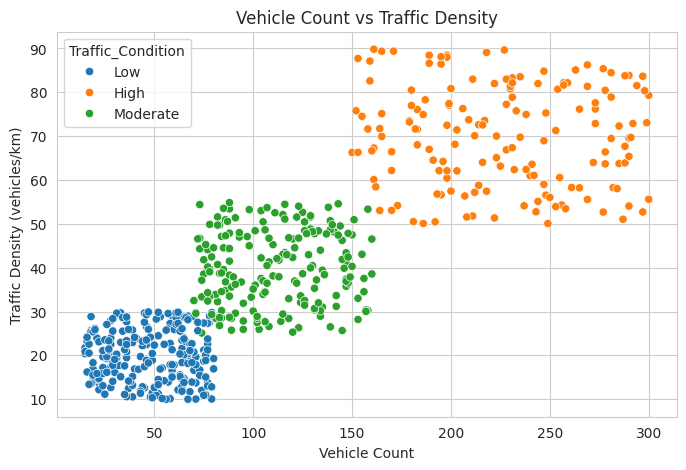

In [27]:
# Compare vehicle count and traffic density

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Vehicle_Count",
    y="Traffic_Density_veh_per_km",
    hue="Traffic_Condition"
)

plt.title("Vehicle Count vs Traffic Density")
plt.xlabel("Vehicle Count")
plt.ylabel("Traffic Density (vehicles/km)")

plt.show()

In [28]:
# Select the main traffic features for analysis

features = [
    "Vehicle_Count",
    "Average_Speed_kmph",
    "Traffic_Density_veh_per_km",
    "Road_Occupancy_percent"
]

traffic_data = df[features]

traffic_data.head()

,Vehicle_Count,Average_Speed_kmph,Traffic_Density_veh_per_km,Road_Occupancy_percent
0,19.0,53.63,16.95,10.64
1,282.0,21.52,58.25,64.57
2,114.0,36.43,27.77,39.43
3,125.0,47.47,52.63,26.83
4,22.0,63.71,13.69,14.19


In [29]:
# Calculate correlation between traffic features

correlation = traffic_data.corr()

print(correlation)

                            Vehicle_Count  Average_Speed_kmph  \
Vehicle_Count                    1.000000           -0.826032   
Average_Speed_kmph              -0.826032            1.000000   
Traffic_Density_veh_per_km       0.850786           -0.816385   
Road_Occupancy_percent           0.846356           -0.820113   

                            Traffic_Density_veh_per_km  Road_Occupancy_percent  
Vehicle_Count                                 0.850786                0.846356  
Average_Speed_kmph                           -0.816385               -0.820113  
Traffic_Density_veh_per_km                    1.000000                0.850038  
Road_Occupancy_percent                        0.850038                1.000000  


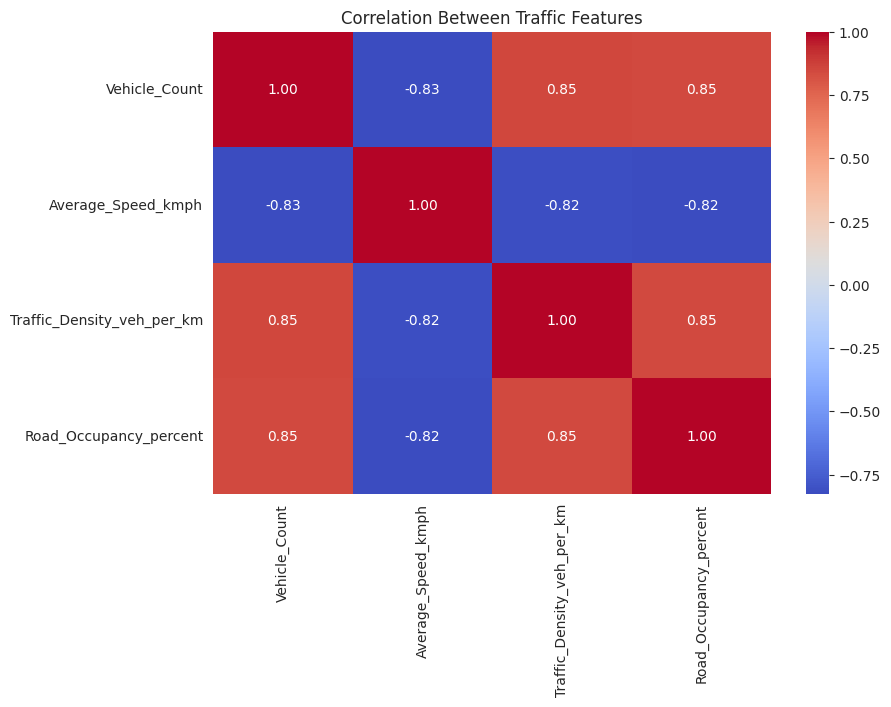

In [30]:
# Create a correlation heatmap

plt.figure(figsize=(9, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Traffic Features")

plt.show()

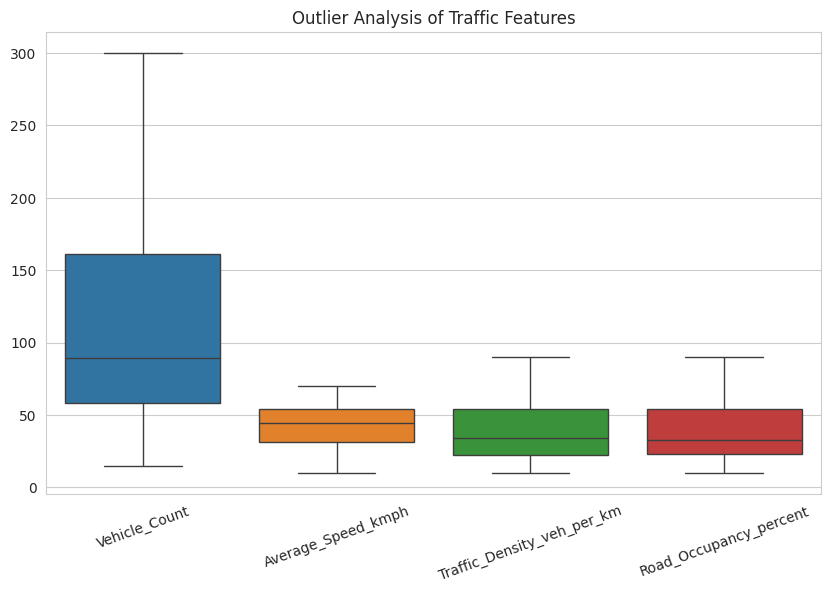

In [31]:
# Create boxplots for the main traffic features

plt.figure(figsize=(10, 6))

sns.boxplot(data=traffic_data)

plt.title("Outlier Analysis of Traffic Features")
plt.xticks(rotation=20)

plt.show()

In [32]:
# Calculate average traffic values for each condition

condition_summary = df.groupby("Traffic_Condition")[features].mean()

condition_summary

,Vehicle_Count,Average_Speed_kmph,Traffic_Density_veh_per_km,Road_Occupancy_percent
Traffic_Condition,,,,
High,225.866242,23.373121,70.023503,69.217516
Low,47.818565,57.518354,20.103038,20.398819
Moderate,111.520619,40.724639,40.086959,39.875052


In [33]:
# Calculate average vehicle count for each hour

hourly_traffic = df.groupby("Hour")["Vehicle_Count"].mean()

hourly_traffic

,Vehicle_Count
Hour,
0,116.545455
1,108.040000
2,132.285714
3,127.333333
4,92.875000
5,91.095238
6,127.045455
7,107.000000
8,94.875000


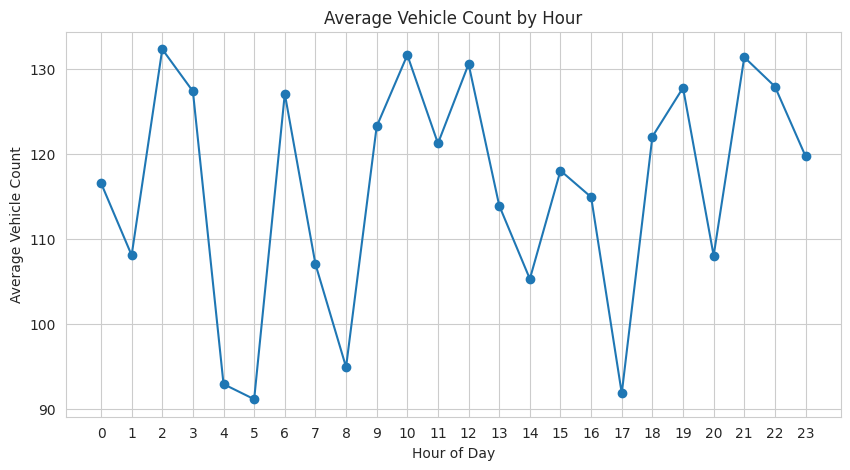

In [34]:
# Plot average vehicle count by hour

plt.figure(figsize=(10, 5))

plt.plot(
    hourly_traffic.index,
    hourly_traffic.values,
    marker="o"
)

plt.title("Average Vehicle Count by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Vehicle Count")

plt.xticks(range(0, 24))

plt.grid(True)

plt.show()

In [35]:
# Final dataset information before machine learning

print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nTraffic Conditions:")
print(df["Traffic_Condition"].value_counts())

Dataset Shape: (588, 8)

Columns:
['Record_ID', 'Hour', 'Day_of_Week', 'Vehicle_Count', 'Average_Speed_kmph', 'Traffic_Density_veh_per_km', 'Road_Occupancy_percent', 'Traffic_Condition']

Missing Values:
Record_ID                     0
Hour                          0
Day_of_Week                   0
Vehicle_Count                 0
Average_Speed_kmph            0
Traffic_Density_veh_per_km    0
Road_Occupancy_percent        0
Traffic_Condition             0
dtype: int64

Duplicate Rows:
0

Traffic Conditions:
Traffic_Condition
Low         237
Moderate    194
High        157
Name: count, dtype: int64
